In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import timm
import matplotlib.pyplot as plt
import numpy as np


from ImageModelUtils import OrderFlowRegressor, RelativeHuberLoss
from ImageEncoding import OrderFlowDataset, ToImage, NormalizedSubset

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'
DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/'
LOCAL_DATA_DIR = '/content/data'

!cp -r {DATA_DIR} {LOCAL_DATA_DIR}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_transform = ToImage(output_size=(600, 160, 3))
base_dataset = OrderFlowDataset(
    f"{LOCAL_DATA_DIR}/train.csv", 
    f"{LOCAL_DATA_DIR}/book_train.parquet", 
    f"{LOCAL_DATA_DIR}/trade_train.parquet", 
    transform=img_transform
)
index_df = pd.DataFrame(base_dataset.index_map, columns=["stock_id", "time_id"])

print(f"Loaded {len(base_dataset)} samples across {index_df['time_id'].nunique()} unique time_id values")

/content/ImageEncoding.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.books = {k : v for k, v in full_book.groupby(['stock_id', 'time_id'])}
/content/ImageEncoding.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.trades = {k : v for k, v in full_trade.groupby(['stock_id', 'time_id'])}


Loaded 428932 samples across 3830 unique time_id values


In [5]:
hyperparameters = {
    "batch_size": 256, 
    "num_workers": os.cpu_count() - 1 if os.cpu_count() else 0, 
    "pin_memory": True, 
    "prefetch_factor": 2
}

In [6]:
# Tumbling-window, time-aware CV helpers.
CV_CONFIG = {
    'n_splits': 5,
    'train_blocks': 3,
    'val_blocks': 1,
    'gap_time_ids': 2,
}

def make_tumbling_time_folds(time_ids, n_splits=5, train_blocks=3, val_blocks=1, gap_time_ids=0):
    unique_times = np.array(sorted(np.unique(time_ids)), dtype=np.int64)
    if unique_times.size == 0:
        return []

    n_chunks = n_splits + train_blocks + val_blocks - 1
    chunks = [c for c in np.array_split(unique_times, n_chunks) if c.size > 0]
    folds = []

    for i in range(n_splits):
        train_chunk_end = i + train_blocks
        val_chunk_end = train_chunk_end + val_blocks
        if val_chunk_end > len(chunks):
            break

        train_times = np.concatenate(chunks[i:train_chunk_end])
        val_times = np.concatenate(chunks[train_chunk_end:val_chunk_end])

        if train_times.size == 0 or val_times.size == 0:
            continue

        if gap_time_ids > 0:
            min_allowed = int(np.max(train_times)) + int(gap_time_ids)
            val_times = val_times[val_times >= min_allowed]
            if val_times.size == 0:
                continue

        folds.append((train_times.astype(np.int64), val_times.astype(np.int64)))

    return folds

def build_fold_indices(index_map, folds):
    time_ids = np.asarray(index_map[:, 1], dtype=np.int64)
    result = []
    for fold_id, (train_times, val_times) in enumerate(folds):
        train_idx = np.where(np.isin(time_ids, train_times))[0]
        val_idx = np.where(np.isin(time_ids, val_times))[0]
        if train_idx.size == 0 or val_idx.size == 0:
            continue
        result.append({
            'fold': fold_id,
            'train_indices': train_idx,
            'val_indices': val_idx,
            'train_times': train_times,
            'val_times': val_times,
        })
    return result

cv_folds = make_tumbling_time_folds(
    index_df['time_id'].to_numpy(),
    n_splits=CV_CONFIG['n_splits'],
    train_blocks=CV_CONFIG['train_blocks'],
    val_blocks=CV_CONFIG['val_blocks'],
    gap_time_ids=CV_CONFIG['gap_time_ids'],
)
cv_fold_indices = build_fold_indices(base_dataset.index_map, cv_folds)
print(f"Prepared {len(cv_fold_indices)} tumbling CV folds")

Prepared 5 tumbling CV folds


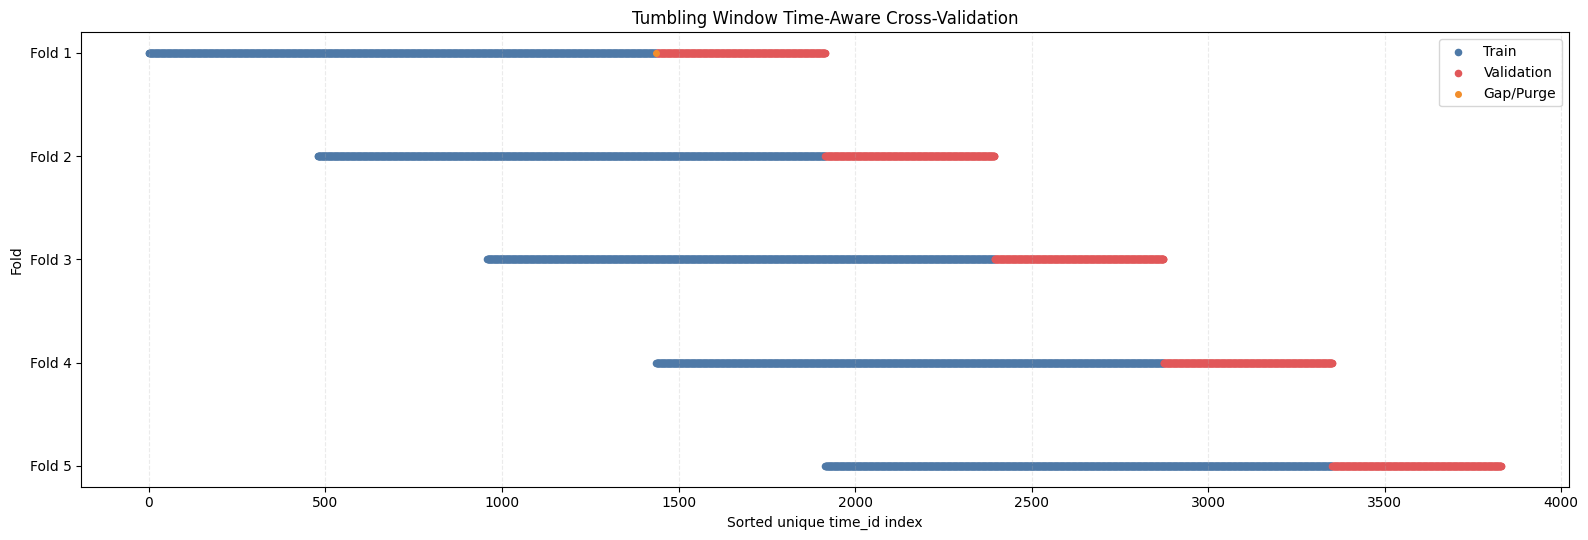

In [7]:
# Visualize tumbling-window fold layout on the time axis.
def visualize_tumbling_folds(folds, all_time_ids):
    if not folds:
        raise ValueError('No folds to visualize. Run tumbling CV helper cell first.')

    unique_times = np.array(sorted(np.unique(all_time_ids)), dtype=np.int64)
    time_to_pos = {int(t): i for i, t in enumerate(unique_times)}

    fig, ax = plt.subplots(figsize=(16, max(4, 1 + 0.9 * len(folds))))
    train_color = '#4e79a7'
    val_color = '#e15759'
    gap_color = '#f28e2b'

    for row, split in enumerate(folds):
        y = len(folds) - 1 - row
        train_times = np.asarray(split['train_times'], dtype=np.int64)
        val_times = np.asarray(split['val_times'], dtype=np.int64)

        train_pos = np.array([time_to_pos[int(t)] for t in train_times if int(t) in time_to_pos], dtype=np.int64)
        val_pos = np.array([time_to_pos[int(t)] for t in val_times if int(t) in time_to_pos], dtype=np.int64)

        if train_pos.size > 0:
            ax.scatter(train_pos, np.full_like(train_pos, y), s=20, color=train_color, label='Train' if row == 0 else None)
        if val_pos.size > 0:
            ax.scatter(val_pos, np.full_like(val_pos, y), s=20, color=val_color, label='Validation' if row == 0 else None)

        if train_times.size > 0 and val_times.size > 0:
            max_train = int(np.max(train_times))
            min_val = int(np.min(val_times))
            gap_times = unique_times[(unique_times > max_train) & (unique_times < min_val)]
            gap_pos = np.array([time_to_pos[int(t)] for t in gap_times], dtype=np.int64)
            if gap_pos.size > 0:
                ax.scatter(gap_pos, np.full_like(gap_pos, y), s=16, color=gap_color, label='Gap/Purge' if row == 0 else None)

    ax.set_yticks(np.arange(len(folds)))
    ax.set_yticklabels([f'Fold {i + 1}' for i in range(len(folds) - 1, -1, -1)])
    ax.set_xlabel('Sorted unique time_id index')
    ax.set_ylabel('Fold')
    ax.set_title('Tumbling Window Time-Aware Cross-Validation')
    ax.grid(axis='x', linestyle='--', alpha=0.25)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

visualize_tumbling_folds(cv_fold_indices, index_df['time_id'].to_numpy())

In [8]:
N_TRIALS = 20

In [9]:
# Hyperparameter optimization (Optuna) for ViT + tabular fusion model.
# Uses multiple tumbling CV folds as the objective split to reduce fold-1 bias.

import optuna
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

def _to_bchw(images: torch.Tensor) -> torch.Tensor:
    if images.ndim == 4 and images.shape[-1] in (3, 4):
        return images.permute(0, 3, 1, 2).contiguous()
    return images

def _resize_width(images: torch.Tensor, n_blocks: int) -> torch.Tensor:
    if images.shape[-1] == n_blocks:
        return images
    return F.interpolate(images, size=(images.shape[-2], n_blocks), mode='bilinear', align_corners=False)

def _build_loader_cfg(batch_size: int, workers: int):
    cfg = {
        'batch_size': batch_size,
        'num_workers': workers,
        'pin_memory': True,
    }
    if workers > 0:
        cfg['prefetch_factor'] = 2
    return cfg

def _build_optimizers(model, adamw_lr, weight_decay, muon_lr):
    muon_params = [p for p in model.parameters() if p.ndim == 2]
    adamw_params = [p for p in model.parameters() if p.ndim != 2]
    optimizer_adamw = optim.AdamW(adamw_params, lr=adamw_lr, weight_decay=weight_decay)

    if hasattr(optim, 'Muon'):
        optimizer_muon = optim.Muon(muon_params, lr=muon_lr, momentum=0.95)
        muon_name = 'Muon'
    else:
        # Fallback keeps matrix-param branch active when Muon is unavailable.
        optimizer_muon = optim.AdamW(muon_params, lr=muon_lr, weight_decay=weight_decay)
        muon_name = 'AdamW(fallback)'

    return optimizer_adamw, optimizer_muon, muon_name

def objective(trial):
    folds_ref = globals().get('cv_fold_indices', [])
    if not folds_ref:
        raise ValueError('No tumbling CV folds available. Run the tumbling CV helper cell before HPO.')

    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    # Keep LR search very small because we are fine-tuning a pretrained ViT.
    adamw_lr = trial.suggest_float('adamw_lr', 2e-6, 5e-5, log=True)
    muon_lr = trial.suggest_float('muon_lr', 5e-6, 1e-4, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 5e-3, log=True)
    huber_delta = trial.suggest_float('huber_delta', 0.05, 0.5)
    warmup_ratio = trial.suggest_float('warmup_ratio', 0.05, 0.2)
    n_blocks = trial.suggest_categorical('n_blocks', [80, 120, 160])
    no_features = trial.suggest_categorical('no_features', [False, True])
    epochs = trial.suggest_int('epochs', 3, 6)

    workers = max(0, (os.cpu_count() or 0) - 1)
    loader_cfg = _build_loader_cfg(batch_size=batch_size, workers=workers)
    feature_dim = int(base_dataset[0]['features'].shape[0])

    # Evaluate each trial on multiple early folds to reduce split-specific bias.
    hpo_fold_count = min(3, len(folds_ref))
    fold_scores = []

    for fold_offset, split in enumerate(folds_ref[:hpo_fold_count]):
        print(f"\n========== Trial {trial.number} | Fold {fold_offset + 1}/{hpo_fold_count} ==========")
        
        train_dataset = torch.utils.data.Subset(base_dataset, split['train_indices'].tolist())
        val_dataset = torch.utils.data.Subset(base_dataset, split['val_indices'].tolist())

        train_loader = DataLoader(train_dataset, shuffle=True, **loader_cfg)
        val_loader = DataLoader(val_dataset, shuffle=False, **loader_cfg)

        model = OrderFlowRegressor(tabular_dim=feature_dim).to(device)
        criterion = RelativeHuberLoss(delta=huber_delta)

        optimizer_adamw, optimizer_muon, _ = _build_optimizers(
            model, adamw_lr=adamw_lr, weight_decay=weight_decay, muon_lr=muon_lr
        )

        total_steps = max(1, len(train_loader) * epochs)
        warmup_steps = max(1, int(warmup_ratio * total_steps))
        decay_steps = max(1, total_steps - warmup_steps)

        def build_scheduler(optimizer):
            warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
            cosine = CosineAnnealingLR(optimizer, T_max=decay_steps, eta_min=1e-6)
            return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_steps])

        scheduler_adamw = build_scheduler(optimizer_adamw)
        scheduler_muon = build_scheduler(optimizer_muon)
        scaler = GradScaler('cuda', enabled=(device.type == 'cuda'))

        best_val = float('inf')

        for epoch in range(epochs):
            model.train()
            
            train_running = 0.0
            
            for batch in train_loader:
                images = _to_bchw(batch['image']).to(device, dtype=torch.float32, non_blocking=True)
                images = _resize_width(images, n_blocks)
                features = batch['features'].to(device, dtype=torch.float32, non_blocking=True)
                if no_features:
                    features = torch.zeros_like(features)
                targets = batch['r_vol'].to(device, dtype=torch.float32, non_blocking=True)

                optimizer_adamw.zero_grad(set_to_none=True)
                optimizer_muon.zero_grad(set_to_none=True)
                with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=(device.type == 'cuda')):
                    preds = model(images, features)
                    loss = criterion(preds, targets)
                    
                train_running += loss.item() * images.size(0)

                scaler.scale(loss).backward()
                scaler.step(optimizer_adamw)
                scaler.step(optimizer_muon)
                scaler.update()
                scheduler_adamw.step()
                scheduler_muon.step()

            model.eval()
            val_running = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    images = _to_bchw(batch['image']).to(device, dtype=torch.float32, non_blocking=True)
                    images = _resize_width(images, n_blocks)
                    features = batch['features'].to(device, dtype=torch.float32, non_blocking=True)
                    if no_features:
                        features = torch.zeros_like(features)
                    targets = batch['r_vol'].to(device, dtype=torch.float32, non_blocking=True)

                    with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=(device.type == 'cuda')):
                        preds = model(images, features)
                        val_loss = criterion(preds, targets)

                    val_running += val_loss.item() * images.size(0)
            epoch_train = train_running / len(train_dataset)
            epoch_val = val_running / len(val_dataset)
            best_val = min(best_val, epoch_val)
            
            print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {epoch_train:.4f} | Val Loss: {epoch_val:.4f} | Best Val: {best_val:.4f}")

            report_step = fold_offset * epochs + epoch
            trial.report(best_val, report_step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        fold_scores.append(best_val)

    return float(np.mean(fold_scores))

sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=2)
study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='vit_fusion_hpo')

study.optimize(objective, n_trials=N_TRIALS, timeout=None, show_progress_bar=True)

print('Best value:', study.best_value)
print('Best params:', study.best_trial.params)

plot_optimization_history(study)
plt.show()
plot_param_importances(study)
plt.show()

df = study.trials_dataframe()
print(df[['number', 'value', 'params_n_blocks', 'params_no_features', 'state']]
      .sort_values('value', ascending=False)
      .to_string(index=False))

ModuleNotFoundError: No module named 'optuna'

In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo
iteration_id = datetime.now(ZoneInfo("America/New_York")).strftime("iter_%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(DIR, "iterations", iteration_id)
os.makedirs(RUN_DIR, exist_ok=True)
DIR = RUN_DIR
print(f"Run artifacts will be saved to: {DIR}")

In [ ]:
def _build_loader_cfg(batch_size: int, workers: int):
    cfg = {
        'batch_size': batch_size,
        'num_workers': workers,
        'pin_memory': True,
    }
    if workers > 0:
        cfg['prefetch_factor'] = 2
    return cfg

def _build_optimizers(model, adamw_lr, weight_decay, muon_lr):
    muon_params = [p for p in model.parameters() if p.ndim == 2]
    adamw_params = [p for p in model.parameters() if p.ndim != 2]
    optimizer_adamw = optim.AdamW(adamw_params, lr=adamw_lr, weight_decay=weight_decay)

    if hasattr(optim, 'Muon'):
        optimizer_muon = optim.Muon(muon_params, lr=muon_lr, momentum=0.95)
        muon_name = 'Muon'
    else:
        optimizer_muon = optim.AdamW(muon_params, lr=muon_lr, weight_decay=weight_decay)
        muon_name = 'AdamW(fallback)'

    return optimizer_adamw, optimizer_muon, muon_name

In [ ]:
def main():
    tuned = {}
    if 'study' in globals() and len(getattr(study, 'trials', [])) > 0 and study.best_trial is not None:
        tuned = study.best_trial.params
        print(f"Loaded tuned params from in-memory Optuna study: {tuned}")
    else:
        print("No Optuna study found in memory. Using default training params.")

    folds_ref = globals().get('cv_fold_indices', [])
    if not folds_ref:
        raise ValueError('No tumbling CV folds available. Run the tumbling CV helper cell first.')

    batch_size = int(tuned.get('batch_size', hyperparameters.get('batch_size', 256)))
    workers = max(0, (os.cpu_count() or 0) - 1)
    local_hparams = _build_loader_cfg(batch_size=batch_size, workers=workers)

    n_blocks = int(tuned.get('n_blocks', 160))
    no_features = bool(tuned.get('no_features', False))

    adamw_lr = float(tuned.get('adamw_lr', 15e-6))
    muon_lr = float(tuned.get('muon_lr', 5e-4))
    weight_decay = float(tuned.get('weight_decay', 0.05))
    warmup_ratio = float(tuned.get('warmup_ratio', 0.1))
    delta = float(tuned.get('huber_delta', 0.2))

    fold_summaries = []
    history_rows = []
    feature_dim = int(base_dataset[0]["features"].shape[0])

    for split in folds_ref:
        fold_id = int(split['fold'])
        print(f"\n{'='*80}")
        print(f"Fold {fold_id + 1}/{len(folds_ref)} | train={len(split['train_indices'])} val={len(split['val_indices'])}")
        print(f"{'='*80}")

        train_dataset = torch.utils.data.Subset(base_dataset, split['train_indices'].tolist())
        val_dataset = torch.utils.data.Subset(base_dataset, split['val_indices'].tolist())

        train_loader = DataLoader(train_dataset, shuffle=True, **local_hparams)
        val_loader = DataLoader(val_dataset, shuffle=False, **local_hparams)

        model = OrderFlowRegressor(tabular_dim=feature_dim).to(device)
        criterion = RelativeHuberLoss(delta=delta)

        optimizer_adamw, optimizer_muon, muon_name = _build_optimizers(
            model, adamw_lr=adamw_lr, weight_decay=weight_decay, muon_lr=muon_lr
        )
        print(f"Fold {fold_id}: secondary optimizer = {muon_name}")

        num_epochs = 20
        total_steps = len(train_loader) * num_epochs
        warmup_steps = max(1, int(warmup_ratio * total_steps))
        decay_steps = max(1, total_steps - warmup_steps)

        def build_scheduler(optimizer):
            warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
            cosine = CosineAnnealingLR(optimizer, T_max=decay_steps)
            return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_steps])

        scheduler_adamw = build_scheduler(optimizer_adamw)
        scheduler_muon = build_scheduler(optimizer_muon)

        best_val_loss = float('inf')
        fold_best_path = f"{DIR}/best_model_fold_{fold_id}.pth"

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            for batch in train_loader:
                images = batch["image"]
                features = batch["features"]
                targets = batch["r_vol"]

                if images.ndim == 4 and images.shape[-1] in (3, 4):
                    images = images.permute(0, 3, 1, 2)
                if images.shape[-1] != n_blocks:
                    images = F.interpolate(images, size=(images.shape[-2], n_blocks), mode='bilinear', align_corners=False)

                images = images.to(device, dtype=torch.float32, non_blocking=True)
                features = features.to(device, dtype=torch.float32, non_blocking=True)
                if no_features:
                    features = torch.zeros_like(features)
                targets = torch.as_tensor(targets, dtype=torch.float32, device=device)

                optimizer_adamw.zero_grad()
                optimizer_muon.zero_grad()

                with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=(device.type == 'cuda')):
                    outputs = model(images, features)
                    loss = criterion(outputs.float(), targets)

                loss.backward()
                optimizer_adamw.step()
                optimizer_muon.step()
                scheduler_adamw.step()
                scheduler_muon.step()
                running_loss += loss.item() * images.size(0)

            train_loss = running_loss / len(train_dataset)

            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    images = batch["image"]
                    features = batch["features"]
                    targets = batch["r_vol"]

                    if images.ndim == 4 and images.shape[-1] in (3, 4):
                        images = images.permute(0, 3, 1, 2)
                    if images.shape[-1] != n_blocks:
                        images = F.interpolate(images, size=(images.shape[-2], n_blocks), mode='bilinear', align_corners=False)

                    images = images.to(device, dtype=torch.float32, non_blocking=True)
                    features = features.to(device, dtype=torch.float32, non_blocking=True)
                    if no_features:
                        features = torch.zeros_like(features)
                    targets = torch.as_tensor(targets, dtype=torch.float32, device=device)

                    with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=(device.type == 'cuda')):
                        outputs = model(images, features)
                        val_loss_tensor = criterion(outputs, targets)

                    running_val_loss += val_loss_tensor.item() * images.size(0)

            val_loss = running_val_loss / len(val_dataset)
            history_rows.append({
                'fold': fold_id,
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'val_loss': val_loss,
            })
            print(f"Fold {fold_id} | Epoch {epoch + 1}/{num_epochs} | Train {train_loss:.6f} | Val {val_loss:.6f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), fold_best_path)

        fold_summaries.append({
            'fold': fold_id,
            'best_val_loss': best_val_loss,
            'num_train_samples': len(split['train_indices']),
            'num_val_samples': len(split['val_indices']),
            'best_model_path': fold_best_path,
        })

    cv_df = pd.DataFrame(fold_summaries).sort_values('fold').reset_index(drop=True)
    cv_scores_path = f"{DIR}/cv_scores_tumbling.csv"
    cv_df.to_csv(cv_scores_path, index=False)
    print(f"Saved tumbling CV summary: {cv_scores_path}")
    print(cv_df.to_string(index=False))

    history_df = pd.DataFrame(history_rows)
    history_path = f"{DIR}/training_history_tumbling.csv"
    history_df.to_csv(history_path, index=False)
    print(f"Saved per-epoch fold history: {history_path}")

In [ ]:
if __name__ == "__main__":
    main()

NameError: name 'main' is not defined